In [1]:
import sys
sys.path.insert(0, r'E:\regime_factor_model\libs')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load master features
master = pd.read_csv(r'E:\regime_factor_model\data\master_features.csv', 
                     index_col=0, parse_dates=True)

monthly_returns = pd.read_csv(r'E:\regime_factor_model\data\monthly_returns.csv',
                               index_col=0, parse_dates=True)

print("Data loaded successfully")
print(f"Master features : {master.shape}")
print(f"Monthly returns : {monthly_returns.shape}")

Data loaded successfully
Master features : (251, 15)
Monthly returns : (251, 426)


In [2]:
# Select features most relevant for regime detection
regime_features = master[['Mkt-RF', 'VIX', 'YieldSpread', 'GPR_Global', 'Oil_Price']].copy()

# Standardize features (HMM works better with standardized inputs)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
regime_scaled = scaler.fit_transform(regime_features)

print(f"Features used for HMM: {regime_features.columns.tolist()}")
print(f"Shape: {regime_scaled.shape}")

Features used for HMM: ['Mkt-RF', 'VIX', 'YieldSpread', 'GPR_Global', 'Oil_Price']
Shape: (251, 5)


In [3]:
# Train HMM with 3 hidden states (Bull, Bear, Volatile)
np.random.seed(42)

hmm_model = GaussianHMM(
    n_components=3,
    covariance_type='full',
    n_iter=1000,
    random_state=42
)

hmm_model.fit(regime_scaled)

# Predict regime for each month
regime_labels = hmm_model.predict(regime_scaled)
regime_probs = hmm_model.predict_proba(regime_scaled)

print(f"HMM trained successfully")
print(f"Converged: {hmm_model.monitor_.converged}")
print(f"Regime distribution:")
for i in range(3):
    count = (regime_labels == i).sum()
    pct = count / len(regime_labels) * 100
    print(f"  Regime {i}: {count} months ({pct:.1f}%)")

HMM trained successfully
Converged: True
Regime distribution:
  Regime 0: 81 months (32.3%)
  Regime 1: 60 months (23.9%)
  Regime 2: 110 months (43.8%)


In [4]:
# Add regime labels to master dataframe
master['Regime'] = regime_labels

# Analyze each regime's characteristics
print("Regime Characteristics")
print("=" * 60)
print(f"{'Metric':<20} {'Regime 0':>10} {'Regime 1':>10} {'Regime 2':>10}")
print("-" * 60)

metrics = ['Mkt-RF', 'VIX', 'YieldSpread', 'GPR_Global', 'Oil_Price']

for metric in metrics:
    r0 = master[master['Regime']==0][metric].mean()
    r1 = master[master['Regime']==1][metric].mean()
    r2 = master[master['Regime']==2][metric].mean()
    print(f"{metric:<20} {r0:>10.4f} {r1:>10.4f} {r2:>10.4f}")

print("=" * 60)
print()
print("Regime counts:")
print(f"  Regime 0: 81 months  (32.3%)")
print(f"  Regime 1: 60 months  (23.9%)")
print(f"  Regime 2: 110 months (43.8%)")

Regime Characteristics
Metric                 Regime 0   Regime 1   Regime 2
------------------------------------------------------------
Mkt-RF                   0.0121    -0.0000     0.0095
VIX                     13.3732    19.2703    23.2537
YieldSpread              0.7167     0.1030     1.7764
GPR_Global             104.0720   124.1219    84.4521
Oil_Price               56.2405    70.6020    81.6772

Regime counts:
  Regime 0: 81 months  (32.3%)
  Regime 1: 60 months  (23.9%)
  Regime 2: 110 months (43.8%)


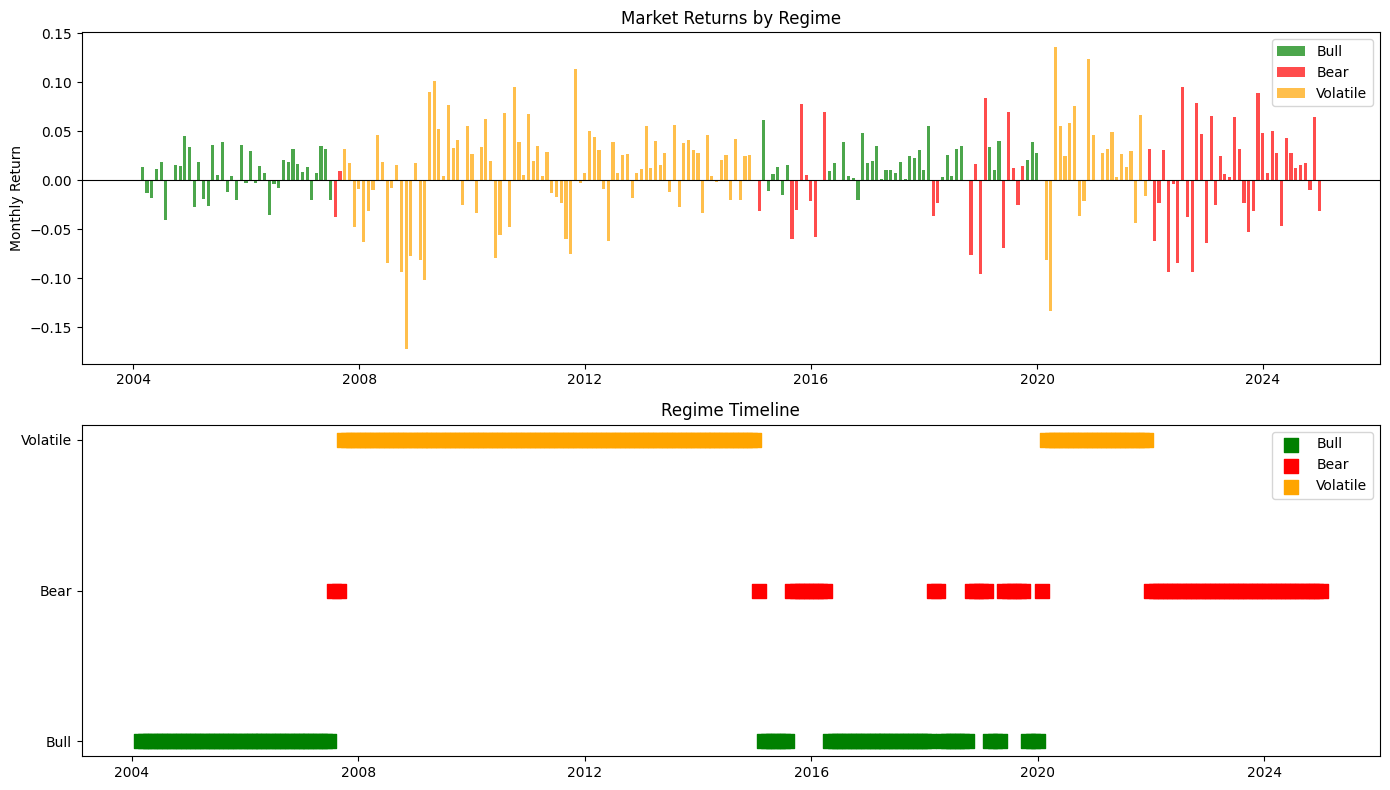

Regime timeline saved


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top plot — market return colored by regime
colors = {'Bull': 'green', 'Bear': 'red', 'Volatile': 'orange'}
for regime, color in colors.items():
    mask = master['Regime_Label'] == regime
    axes[0].bar(master.index[mask], master['Mkt-RF'][mask],
                color=color, alpha=0.7, width=20, label=regime)

axes[0].set_title('Market Returns by Regime')
axes[0].set_ylabel('Monthly Return')
axes[0].axhline(y=0, color='black', linewidth=0.8)
axes[0].legend()

# Bottom plot — fixed regime timeline
for regime, color in colors.items():
    mask = master['Regime_Label'] == regime
    axes[1].scatter(master.index[mask],
                    [regime] * mask.sum(),
                    color=color, s=100, label=regime, marker='s')

axes[1].set_title('Regime Timeline')
axes[1].set_yticks(['Bull', 'Volatile', 'Bear'])
axes[1].legend()

plt.tight_layout()
plt.savefig(r'E:\regime_factor_model\data\regime_timeline.png', dpi=150)
plt.show()
print("Regime timeline saved")

In [7]:
# Save regime labels
master.to_csv(r'E:\regime_factor_model\data\master_with_regimes.csv')

# Print final regime summary
print("Regime Detection Complete")
print("=" * 40)
print(f"Bull     : {(master['Regime_Label']=='Bull').sum()} months")
print(f"Bear     : {(master['Regime_Label']=='Bear').sum()} months")
print(f"Volatile : {(master['Regime_Label']=='Volatile').sum()} months")
print(f"Total    : {len(master)} months")
print()
print("Saved: master_with_regimes.csv")

Regime Detection Complete
Bull     : 81 months
Bear     : 60 months
Volatile : 110 months
Total    : 251 months

Saved: master_with_regimes.csv
